In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

# 전체 과정 시각화

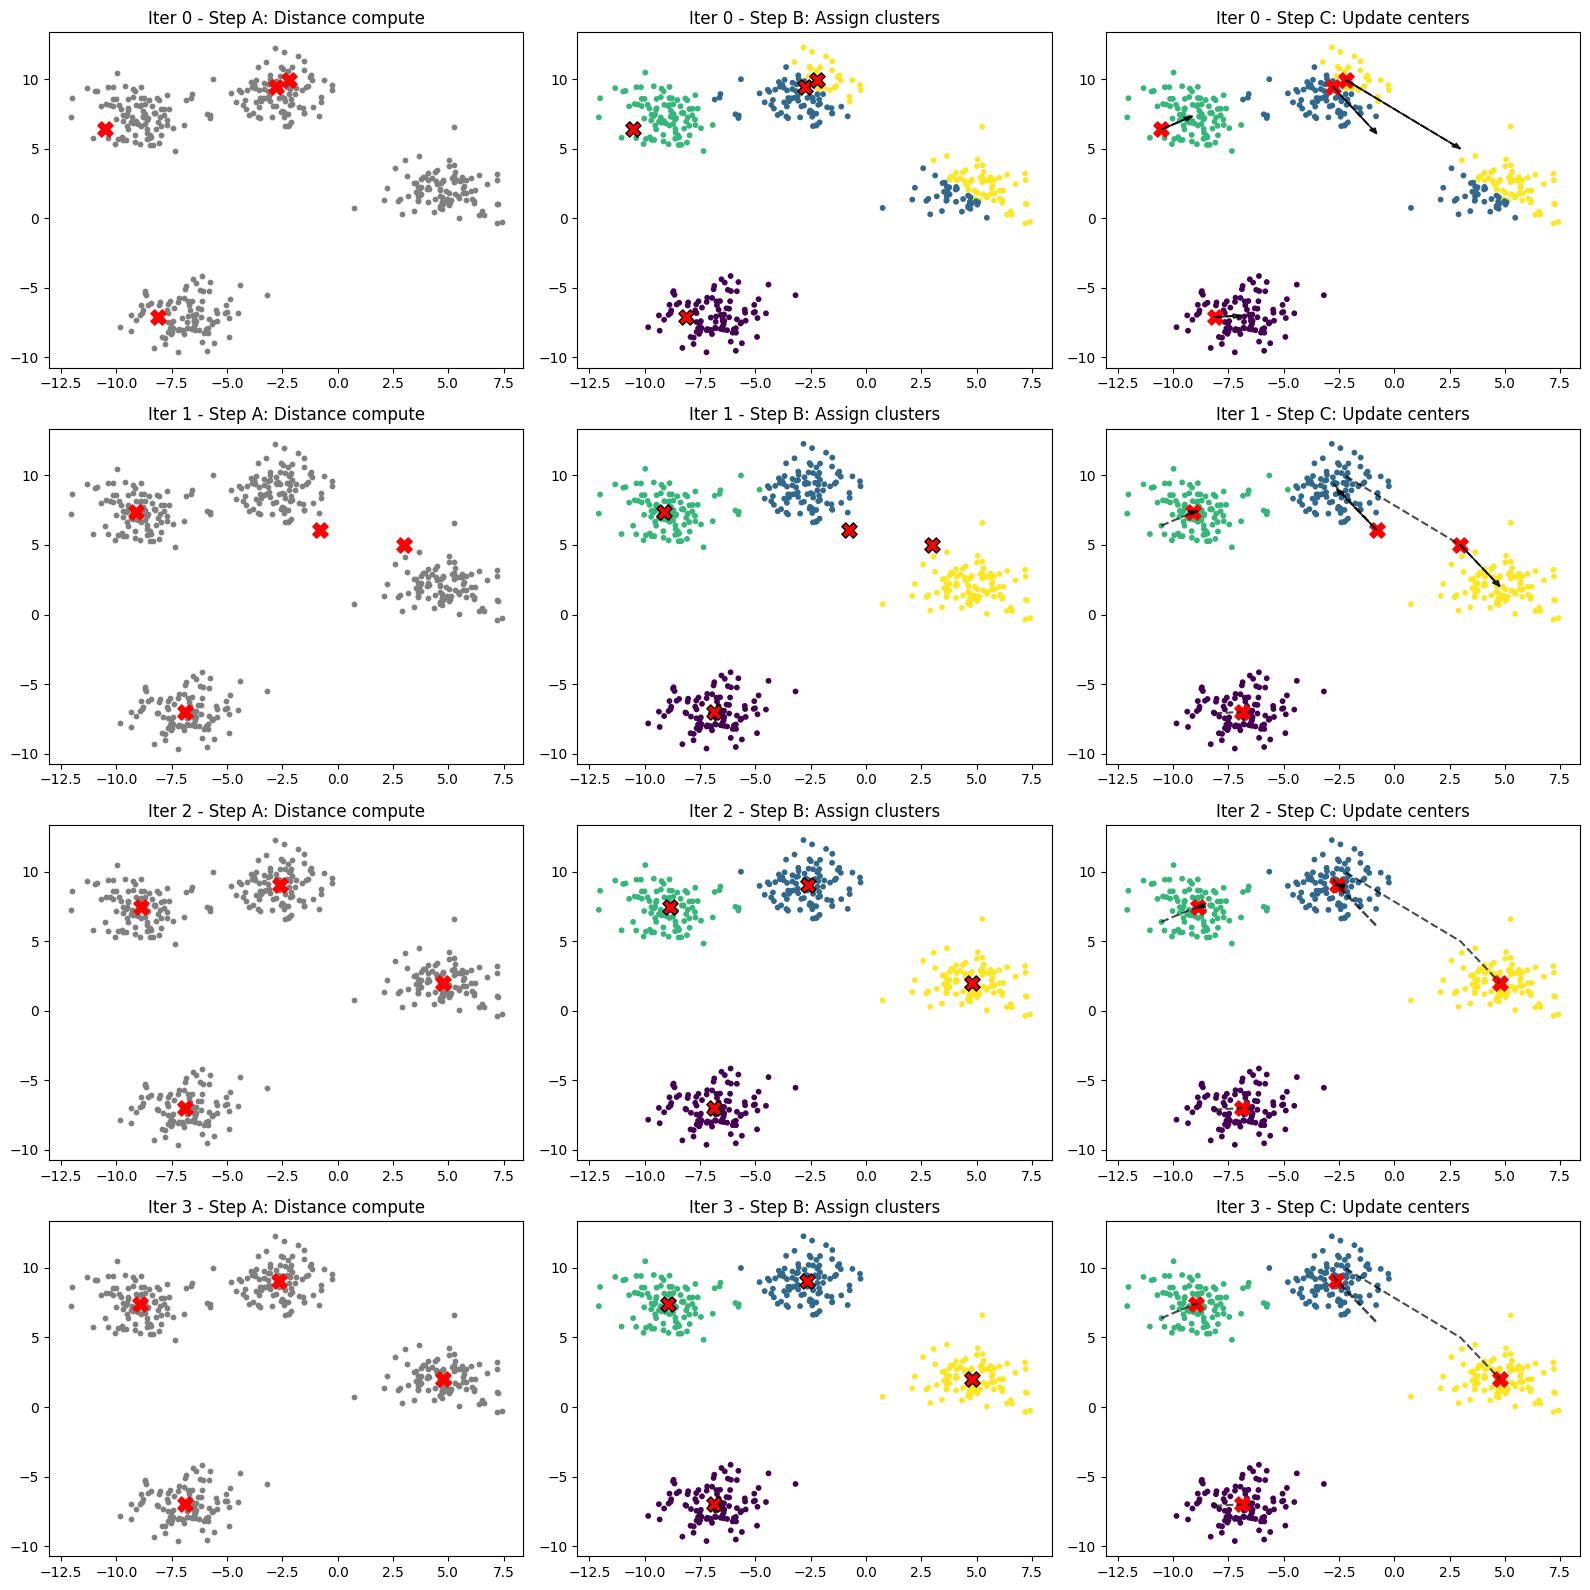

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import math

# ===========================================
# 1) 데이터 생성
# ===========================================
X, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

k = 4
max_iters = 10
np.random.seed(42)

# 초기 중심
indices = np.random.choice(len(X), size=k, replace=False)
centers = X[indices]

def compute_distances(X, centers):
    return np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)

def assign_clusters(distances):
    return np.argmin(distances, axis=1)

def update_centers(X, labels):
    new_centers = np.zeros((k, X.shape[1]))
    for i in range(k):
        pts = X[labels == i]
        if len(pts) > 0:
            new_centers[i] = pts.mean(axis=0)
        else:
            new_centers[i] = X[np.random.randint(len(X))]
    return new_centers


# ===========================================
# 전체 과정 history 저장
# ===========================================
dist_hist = []
label_hist = []
center_hist = []
center_paths = [[] for _ in range(k)]

for i in range(k):
    center_paths[i].append(centers[i].copy())

for it in range(max_iters):

    # Step A: 거리 계산
    dists = compute_distances(X, centers)
    dist_hist.append(dists.copy())

    # Step B: 클러스터 할당
    labels = assign_clusters(dists)
    label_hist.append(labels.copy())

    # 기록
    center_hist.append(centers.copy())

    # Step C: 중심 업데이트
    new_centers = update_centers(X, labels)
    for i in range(k):
        center_paths[i].append(new_centers[i].copy())

    if np.allclose(centers, new_centers, atol=1e-3):
        center_hist.append(new_centers.copy())
        break

    centers = new_centers

num_iters = len(label_hist)
num_frames = num_iters * 3   # Step A/B/C 반복

rows = math.ceil(num_frames / 3)
fig, axes = plt.subplots(rows, 3, figsize=(16, 4*rows))
axes = axes.flatten()

# ===========================================
# 그림 하나하나 채우기
# ===========================================
frame_idx = 0
for it in range(num_iters):

    # -----------------------
    # Step A : 거리 기반 최근접 확인
    # -----------------------
    ax = axes[frame_idx]
    ax.scatter(X[:, 0], X[:, 1], s=10, c="gray")
    ax.scatter(center_hist[it][:,0], center_hist[it][:,1],
               c="red", s=120, marker="X")
    ax.set_title(f"Iter {it} - Step A: Distance compute")
    frame_idx += 1

    # -----------------------
    # Step B : 클러스터 할당
    # -----------------------
    ax = axes[frame_idx]
    ax.scatter(X[:, 0], X[:, 1], c=label_hist[it], cmap="viridis", s=10)
    ax.scatter(center_hist[it][:,0], center_hist[it][:,1],
               c="red", s=120, marker="X", edgecolor="black")
    ax.set_title(f"Iter {it} - Step B: Assign clusters")
    frame_idx += 1

    # -----------------------
    # Step C : 중심 업데이트 (이동 과정)
    # -----------------------
    ax = axes[frame_idx]
    ax.scatter(X[:, 0], X[:, 1], c=label_hist[it], cmap="viridis", s=10)

    # 중심 표시
    old_c = center_hist[it]
    new_c = center_paths[0][it+1].copy()  # 예: path 기록

    ax.scatter(old_c[:,0], old_c[:,1], c="red", s=120, marker="X")

    # 중심 이동 화살표
    for j in range(k):
        oc = center_hist[it][j]
        nc = center_paths[j][it+1]
        ax.arrow(
            oc[0], oc[1],
            nc[0] - oc[0], nc[1] - oc[1],
            length_includes_head=True,
            head_width=0.3, head_length=0.4,
            color="black", alpha=0.8
        )

    # 중심 이동 경로 전체
    for j in range(k):
        path = np.array(center_paths[j][:it+2])
        ax.plot(path[:,0], path[:,1], "--", color="black", alpha=0.7)

    ax.set_title(f"Iter {it} - Step C: Update centers")
    frame_idx += 1


# 마지막 남은 subplot은 자동 비활성화
for i in range(frame_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# 과정 애니매이션

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs
from IPython.display import HTML

# =========================
# 데이터 생성
# =========================
X, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

k = 4
max_iters = 20
np.random.seed(42)

# 초기 중심
indices = np.random.choice(len(X), size=k, replace=False)
centers = X[indices]

def compute_distances(X, centers):
    return np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2)

def assign_clusters(distances):
    return np.argmin(distances, axis=1)

def update_centers(X, labels):
    new = np.zeros((k, X.shape[1]))
    for i in range(k):
        pts = X[labels == i]
        if len(pts) > 0:
            new[i] = pts.mean(axis=0)
        else:
            new[i] = X[np.random.randint(len(X))]
    return new


# =========================
# iteration 전체 기록
# =========================
center_hist = []
label_hist = []
center_paths = [[] for _ in range(k)]

for i in range(k):
    center_paths[i].append(centers[i].copy())

for it in range(max_iters):
    d = compute_distances(X, centers)
    labels = assign_clusters(d)

    center_hist.append(centers.copy())
    label_hist.append(labels.copy())

    new_centers = update_centers(X, labels)

    for i in range(k):
        center_paths[i].append(new_centers[i].copy())

    if np.allclose(centers, new_centers, atol=1e-3):
        break

    centers = new_centers

num_iters = len(label_hist)


# =========================
# 애니메이션
# =========================
fig, ax = plt.subplots(figsize=(7,6))

def animate(frame):
    ax.clear()
    labels = label_hist[frame]
    ctrs = center_hist[frame]

    # 데이터 점
    ax.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=18)

    # 중심
    ax.scatter(ctrs[:,0], ctrs[:,1],
               c='red', s=150, marker='X', edgecolor='black')

    # 경로
    for i in range(k):
        path = np.array(center_paths[i][:frame+1])
        ax.plot(path[:,0], path[:,1], '--', color='black')

    # 화살표(중심 이동)
    if frame > 0:
        oc = center_hist[frame-1]
        nc = center_hist[frame]
        for i in range(k):
            ax.arrow(
                oc[i,0], oc[i,1],
                nc[i,0] - oc[i,0],
                nc[i,1] - oc[i,1],
                head_width=0.3, head_length=0.4,
                length_includes_head=True,
                color='black'
            )

    ax.set_xlim(X[:,0].min()-2, X[:,0].max()+2)
    ax.set_ylim(X[:,1].min()-2, X[:,1].max()+2)
    ax.set_title(f"K-means Iteration {frame}")

anim = FuncAnimation(fig, animate, frames=num_iters, interval=800)

HTML(anim.to_jshtml())

# 데이터 로드

In [ ]:
# ---- 2차원 데이터 ----
X2, y2 = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

# ---- 3차원 데이터 ----
X3, y3 = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=1.3,
    n_features=3,
    random_state=42
)

df2 = pd.DataFrame(X2, columns=["x1", "x2"])
df3 = pd.DataFrame(X3, columns=["x1", "x2", "x3"])

# Elbow Method

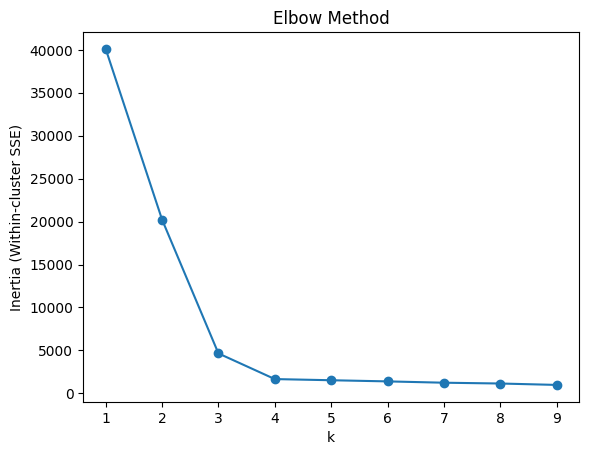

In [ ]:
inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X2)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method")
plt.show()

# 실루엣 점수

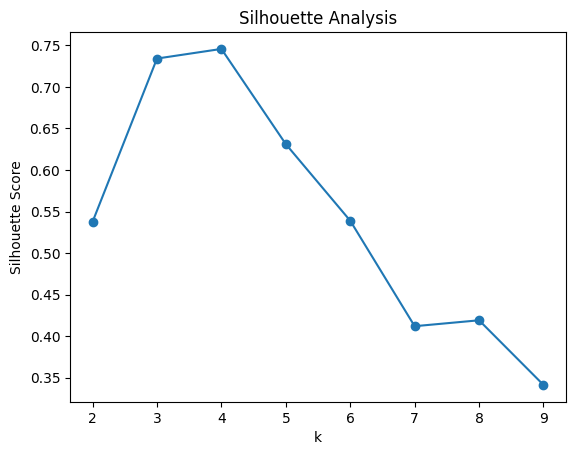

In [ ]:
sil_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X2)
    sil = silhouette_score(X2, labels)
    sil_scores.append(sil)

plt.plot(range(2, 10), sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

# K-means

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X2)
centers = kmeans.cluster_centers_

# 2d 시각화

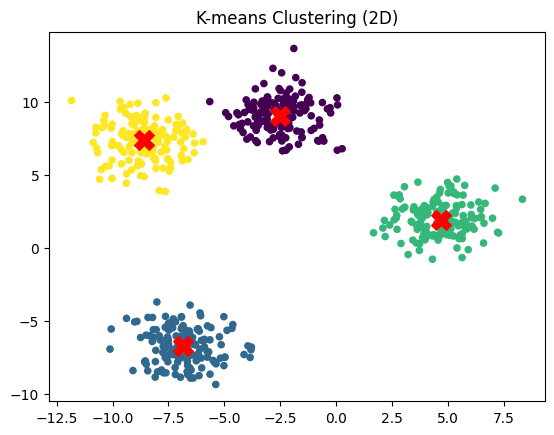

In [ ]:
plt.scatter(X2[:, 0], X2[:, 1], c=labels, cmap="viridis", s=20)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
plt.title("K-means Clustering (2D)")
plt.show()

# 3d 시각화

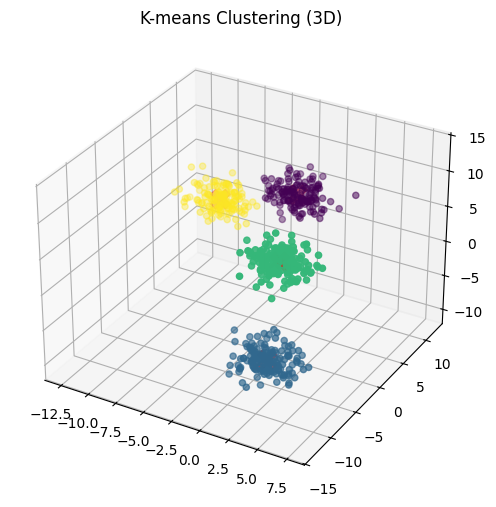

In [ ]:
kmeans_3d = KMeans(n_clusters=4, random_state=42)
labels_3d = kmeans_3d.fit_predict(X3)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X3[:,0], X3[:,1], X3[:,2], c=labels_3d, cmap='viridis', s=20)
ax.scatter(kmeans_3d.cluster_centers_[:,0],
           kmeans_3d.cluster_centers_[:,1],
           kmeans_3d.cluster_centers_[:,2],
           c='red', s=200, marker='X')

ax.set_title("K-means Clustering (3D)")
plt.show()

# 각 클러스터 분석

In [ ]:
df2["cluster"] = labels

summary = df2.groupby("cluster").agg(["mean", "std", "min", "max"])
print(summary)

               x1                                       x2            \
             mean       std        min       max      mean       std   
cluster                                                                
0       -2.532398  1.123766  -5.652892  0.268393  9.042360  1.195850   
1       -6.848837  1.176641 -10.115891 -3.791595 -6.736276  1.195106   
2        4.672010  1.192293   1.673905  8.334536  1.923745  1.141966   
3       -8.610375  1.113372 -11.837615 -5.954229  7.340818  1.299943   

                              
              min        max  
cluster                       
0        6.629203  13.637564  
1       -9.368178  -3.721251  
2       -0.789136   4.698001  
3        3.848016  10.251226  


# 새로운 포인트 클러스터 확인

In [ ]:
new_points = np.array([
    [0, 0],
    [5, -3],
    [-2, 7]
])

pred = kmeans.predict(new_points)
print("새 포인트의 클러스터:", pred)

새 포인트의 클러스터: [2 2 0]


In [ ]:
dist = kmeans.transform(new_points)     # shape = (n_samples, k)
print("각 포인트별 클러스터 거리:\n", dist)

각 포인트별 클러스터 거리:
 [[ 9.39027721  9.60645508  5.05257124 11.3148648 ]
 [14.20406423 12.42395639  4.93465761 17.09312209]
 [ 2.11061134 14.56696585  8.38356022  6.61915501]]
